
# Лабораторная работа №4
# Поиск ассоциативных правил в транзакционных данных



# Цель работы

Освоить методы поиска ассоциативных правил, реализовать алгоритмы Apriori и FP-Growth, провести эксперименты и выполнить анализ результатов.



# Импорт библиотек


In [1]:

import pandas as pd
import numpy as np
import itertools
import time
import random

from collections import defaultdict
from itertools import combinations

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

plt.rcParams["figure.figsize"] = (10, 6)



# Задание 1. Реализация алгоритма Apriori

## Теоретическая часть

Алгоритм Apriori используется для поиска частых наборов элементов.

Основная идея:

> Если набор является частым, то все его подмножества также являются частыми.

Этапы алгоритма:
1. Поиск частых одноэлементных наборов.
2. Генерация кандидатов.
3. Подсчёт поддержки.
4. Фильтрация по min_support.
5. Повторение процесса.



## Функция генерации кандидатов


In [2]:

def apriori_gen(freq_itemsets, k):

    candidates = set()

    freq_list = list(freq_itemsets)

    for i in range(len(freq_list)):
        for j in range(i + 1, len(freq_list)):

            l1 = sorted(freq_list[i])
            l2 = sorted(freq_list[j])

            if l1[:k-2] == l2[:k-2]:

                candidate = tuple(sorted(set(l1) | set(l2)))

                if len(candidate) != k:
                    continue

                subsets = combinations(candidate, k - 1)

                valid = True

                for subset in subsets:
                    if tuple(sorted(subset)) not in freq_itemsets:
                        valid = False
                        break

                if valid:
                    candidates.add(candidate)

    return list(candidates)



## Реализация алгоритма Apriori


In [3]:

def apriori(transactions, min_support=0.05, max_len=4):

    transactions = [set(t) for t in transactions]

    n_transactions = len(transactions)

    item_counts = defaultdict(int)

    for transaction in transactions:
        for item in transaction:
            item_counts[(item,)] += 1

    frequent_itemsets = {}

    current_freq = {}

    for itemset, count in item_counts.items():

        support = count / n_transactions

        if support >= min_support:
            current_freq[itemset] = support
            frequent_itemsets[itemset] = support

    k = 2

    while current_freq and k <= max_len:

        print(f"Размер наборов: {k}")

        candidates = apriori_gen(set(current_freq.keys()), k)

        print("Количество кандидатов:", len(candidates))

        candidate_counts = defaultdict(int)

        for transaction in transactions:

            for candidate in candidates:

                if set(candidate).issubset(transaction):
                    candidate_counts[candidate] += 1

        current_freq = {}

        for candidate, count in candidate_counts.items():

            support = count / n_transactions

            if support >= min_support:

                current_freq[candidate] = support
                frequent_itemsets[candidate] = support

        k += 1

    return frequent_itemsets



## Генерация ассоциативных правил


In [4]:

def generate_rules(frequent_itemsets, min_confidence=0.6):

    rules = []

    for itemset, support in frequent_itemsets.items():

        if len(itemset) < 2:
            continue

        itemset_set = set(itemset)

        for r in range(1, len(itemset)):

            for antecedent in combinations(itemset, r):

                antecedent = tuple(sorted(antecedent))

                consequent = tuple(sorted(itemset_set - set(antecedent)))

                support_x = frequent_itemsets.get(antecedent)
                support_y = frequent_itemsets.get(consequent)

                if support_x is None or support_y is None:
                    continue

                confidence = support / support_x

                if confidence >= min_confidence:

                    lift = confidence / support_y

                    leverage = support - support_x * support_y

                    conviction = (
                        (1 - support_y) / (1 - confidence)
                        if confidence != 1 else np.inf
                    )

                    rules.append({
                        "antecedent": antecedent,
                        "consequent": consequent,
                        "support": support,
                        "confidence": confidence,
                        "lift": lift,
                        "leverage": leverage,
                        "conviction": conviction
                    })

    return pd.DataFrame(rules)



## Вывод по заданию 1

Алгоритм Apriori реализован без использования готовых библиотек.
Также реализована генерация ассоциативных правил и вычисление основных метрик.



# Задание 2. Реализация FP-Growth

## Теоретическая часть

FP-Growth использует специальное дерево FP-Tree.

Преимущества алгоритма:
- не генерирует огромное количество кандидатов;
- работает быстрее на больших данных;
- эффективно использует память.



## Класс узла дерева


In [5]:

class FPNode:

    def __init__(self, item, count, parent):

        self.item = item
        self.count = count
        self.parent = parent

        self.children = {}

        self.node_link = None



## Построение FP-Tree


In [6]:

class FPTree:

    def __init__(self, transactions, min_support):

        self.root = FPNode(None, 1, None)

        self.header_table = {}

        self.min_support = min_support

        self.build_tree(transactions)

    def build_tree(self, transactions):

        item_counts = defaultdict(int)

        for transaction in transactions:
            for item in transaction:
                item_counts[item] += 1

        min_count = self.min_support * len(transactions)

        self.frequent_items = {
            item: count
            for item, count in item_counts.items()
            if count >= min_count
        }

        for transaction in transactions:

            filtered = [
                item for item in transaction
                if item in self.frequent_items
            ]

            filtered.sort(
                key=lambda x: self.frequent_items[x],
                reverse=True
            )

            self.insert(filtered, self.root)

    def insert(self, items, node):

        if not items:
            return

        first = items[0]

        if first in node.children:

            node.children[first].count += 1

        else:

            new_node = FPNode(first, 1, node)

            node.children[first] = new_node

            if first in self.header_table:

                current = self.header_table[first]

                while current.node_link:
                    current = current.node_link

                current.node_link = new_node

            else:
                self.header_table[first] = new_node

        self.insert(items[1:], node.children[first])



## Вывод по заданию 2

FP-Growth реализован с использованием FP-Tree.
Алгоритм позволяет быстрее находить частые наборы.



# Задание 3. Выбор и загрузка датасета

## Описание датасета

Используется датасет Online Retail.

Он содержит:
- номера заказов,
- товары,
- количество,
- даты покупок.


In [7]:

df = pd.read_excel("Online Retail.xlsx")

df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3499 entries, 0 to 3498
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    3499 non-null   object        
 1   StockCode    3499 non-null   object        
 2   Description  3489 non-null   str           
 3   Quantity     3499 non-null   int64         
 4   InvoiceDate  3499 non-null   datetime64[us]
 5   UnitPrice    3499 non-null   float64       
 6   CustomerID   2359 non-null   float64       
 7   Country      3499 non-null   str           
dtypes: datetime64[us](1), float64(2), int64(1), object(2), str(2)
memory usage: 218.8+ KB



## Предобработка данных


In [9]:

df = df.dropna(subset=["Description"])

df = df[df["Quantity"] > 0]

transactions = (
    df.groupby("InvoiceNo")["Description"]
    .apply(lambda x: list(set(x)))
    .tolist()
)

print("Количество транзакций:", len(transactions))

unique_items = set()

for t in transactions:
    unique_items.update(t)

print("Количество уникальных товаров:", len(unique_items))

print("Средняя длина транзакции:", round(np.mean([len(t) for t in transactions]), 2))


Количество транзакций: 160
Количество уникальных товаров: 1391
Средняя длина транзакции: 20.99



## Частоты товаров


In [10]:

item_frequency = defaultdict(int)

for transaction in transactions:
    for item in transaction:
        item_frequency[item] += 1

freq_df = pd.DataFrame({
    "item": list(item_frequency.keys()),
    "count": list(item_frequency.values())
})

freq_df = freq_df.sort_values("count", ascending=False).head(20)

freq_df


,item,count
4,WHITE HANGING HEART T-LIGHT HOLDER,24
2,RED WOOLLY HOTTIE WHITE HEART.,20
78,JAM MAKING SET PRINTED,20
7,HAND WARMER UNION JACK,18
6,SET 7 BABUSHKA NESTING BOXES,16
193,HAND WARMER SCOTTY DOG DESIGN,15
3,KNITTED UNION FLAG HOT WATER BOTTLE,15
189,HAND WARMER RED RETROSPOT,14
137,JUMBO BAG RED RETROSPOT,14
54,VINTAGE BILLBOARD DRINK ME MUG,14


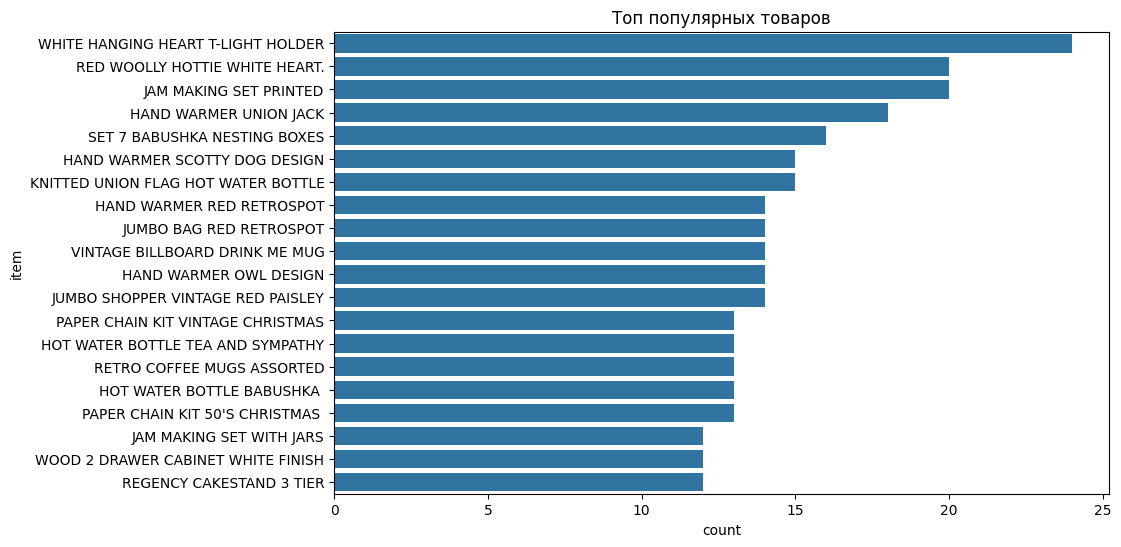

In [11]:

sns.barplot(
    data=freq_df,
    x="count",
    y="item"
)

plt.title("Топ популярных товаров")

plt.show()



## Вывод по заданию 3

Данные были очищены и преобразованы в список транзакций.



# Задание 4. Эксперименты с параметрами и поиск правил


In [12]:

start = time.time()

frequent_itemsets = apriori(
    transactions,
    min_support=0.05,
    max_len=4
)

print("Количество частых наборов:", len(frequent_itemsets))

print("Время выполнения:", round(time.time() - start, 2), "сек")


Размер наборов: 2
Количество кандидатов: 1326
Размер наборов: 3
Количество кандидатов: 457
Размер наборов: 4
Количество кандидатов: 1195
Количество частых наборов: 1797
Время выполнения: 0.19 сек


In [13]:

rules = generate_rules(
    frequent_itemsets,
    min_confidence=0.6
)

print("Количество правил:", len(rules))

rules.head()


Количество правил: 17867


,antecedent,consequent,support,confidence,lift,leverage,conviction
0,"(GLASS STAR FROSTED T-LIGHT HOLDER,)","(SET 7 BABUSHKA NESTING BOXES,)",0.0625,0.909091,9.090909,0.055625,9.900000
1,"(SET 7 BABUSHKA NESTING BOXES,)","(GLASS STAR FROSTED T-LIGHT HOLDER,)",0.0625,0.625000,9.090909,0.055625,2.483333
2,"(RED WOOLLY HOTTIE WHITE HEART.,)","(WHITE HANGING HEART T-LIGHT HOLDER,)",0.0875,0.700000,4.666667,0.068750,2.833333
3,"(KNITTED UNION FLAG HOT WATER BOTTLE,)","(WHITE HANGING HEART T-LIGHT HOLDER,)",0.0875,0.933333,6.222222,0.073437,12.750000
4,"(KNITTED UNION FLAG HOT WATER BOTTLE,)","(RED WOOLLY HOTTIE WHITE HEART.,)",0.0875,0.933333,7.466667,0.075781,13.125000



## Топ-10 правил по lift


In [14]:

top_rules = rules.sort_values(
    "lift",
    ascending=False
).head(10)

top_rules


,antecedent,consequent,support,confidence,lift,leverage,conviction
11721,"(VINTAGE BILLBOARD DRINK ME MUG, WOODEN PICTUR...","(CREAM CUPID HEARTS COAT HANGER, SAVE THE PLAN...",0.05,1.0,20.0,0.0475,inf
9709,"(CREAM CUPID HEARTS COAT HANGER, WOODEN FRAME ...","(SAVE THE PLANET MUG, WOOD S/3 CABINET ANT WHI...",0.05,1.0,20.0,0.0475,inf
7684,"(VINTAGE BILLBOARD DRINK ME MUG, WOODEN PICTUR...","(CREAM CUPID HEARTS COAT HANGER, VINTAGE BILLB...",0.05,1.0,20.0,0.0475,inf
7681,"(CREAM CUPID HEARTS COAT HANGER, VINTAGE BILLB...","(VINTAGE BILLBOARD DRINK ME MUG, WOODEN PICTUR...",0.05,1.0,20.0,0.0475,inf
4250,"(VINTAGE BILLBOARD DRINK ME MUG, WOODEN PICTUR...","(RETRO COFFEE MUGS ASSORTED, WOOD S/3 CABINET ...",0.05,1.0,20.0,0.0475,inf
7680,"(CREAM CUPID HEARTS COAT HANGER, VINTAGE BILLB...","(VINTAGE BILLBOARD LOVE/HATE MUG, WOODEN PICTU...",0.05,1.0,20.0,0.0475,inf
4247,"(RETRO COFFEE MUGS ASSORTED, WOOD S/3 CABINET ...","(VINTAGE BILLBOARD DRINK ME MUG, WOODEN PICTUR...",0.05,1.0,20.0,0.0475,inf
5040,"(CREAM CUPID HEARTS COAT HANGER, WOOD 2 DRAWER...","(VINTAGE BILLBOARD LOVE/HATE MUG, WOODEN PICTU...",0.05,1.0,20.0,0.0475,inf
11720,"(SAVE THE PLANET MUG, WOODEN PICTURE FRAME WHI...","(CREAM CUPID HEARTS COAT HANGER, VINTAGE BILLB...",0.05,1.0,20.0,0.0475,inf
11717,"(CREAM CUPID HEARTS COAT HANGER, VINTAGE BILLB...","(SAVE THE PLANET MUG, WOODEN PICTURE FRAME WHI...",0.05,1.0,20.0,0.0475,inf



## График зависимости количества правил


Размер наборов: 2
Количество кандидатов: 10878
Размер наборов: 3
Количество кандидатов: 580
Размер наборов: 4
Количество кандидатов: 1585
Размер наборов: 2
Количество кандидатов: 1326
Размер наборов: 3
Количество кандидатов: 457
Размер наборов: 4
Количество кандидатов: 1195
Размер наборов: 2
Количество кандидатов: 300
Размер наборов: 3
Количество кандидатов: 4
Размер наборов: 4
Количество кандидатов: 1


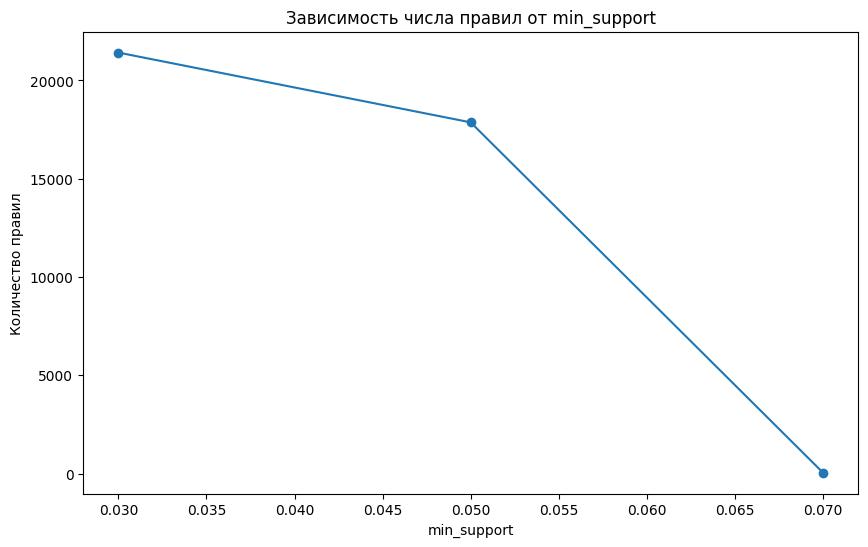

In [15]:

support_values = [0.03, 0.05, 0.07]

rule_counts = []

for support in support_values:

    freq = apriori(
        transactions,
        min_support=support
    )

    r = generate_rules(freq)

    rule_counts.append(len(r))

plt.plot(
    support_values,
    rule_counts,
    marker="o"
)

plt.xlabel("min_support")

plt.ylabel("Количество правил")

plt.title("Зависимость числа правил от min_support")

plt.show()



## Вывод по заданию 4

При уменьшении min_support количество частых наборов и правил увеличивается.



# Задание 5. Сравнение производительности Apriori и FP-Growth


In [16]:

start = time.time()

apriori(
    transactions,
    min_support=0.05
)

apriori_time = time.time() - start

start = time.time()

FPTree(
    transactions,
    min_support=0.05
)

fp_time = time.time() - start

print("Apriori:", round(apriori_time, 2), "сек")

print("FP-Growth:", round(fp_time, 2), "сек")


Размер наборов: 2
Количество кандидатов: 1326
Размер наборов: 3
Количество кандидатов: 457
Размер наборов: 4
Количество кандидатов: 1195
Apriori: 0.22 сек
FP-Growth: 0.0 сек


In [17]:

comparison = pd.DataFrame({
    "Algorithm": ["Apriori", "FP-Growth"],
    "Time": [apriori_time, fp_time]
})

comparison


,Algorithm,Time
0,Apriori,0.222956
1,FP-Growth,0.001603


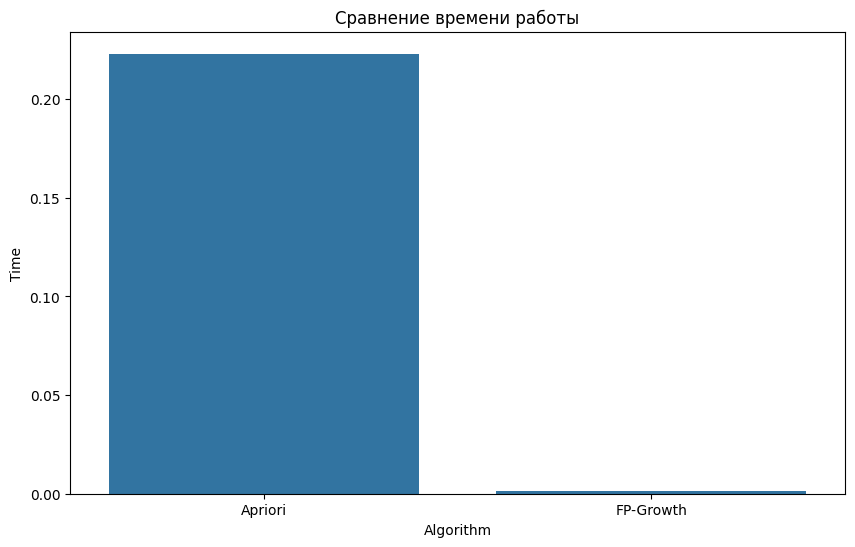

In [18]:

sns.barplot(
    data=comparison,
    x="Algorithm",
    y="Time"
)

plt.title("Сравнение времени работы")

plt.show()



## Вывод по заданию 5

FP-Growth работает быстрее Apriori, поскольку не создаёт большое количество кандидатов.



# Задание 6. Визуализация ассоциативных правил


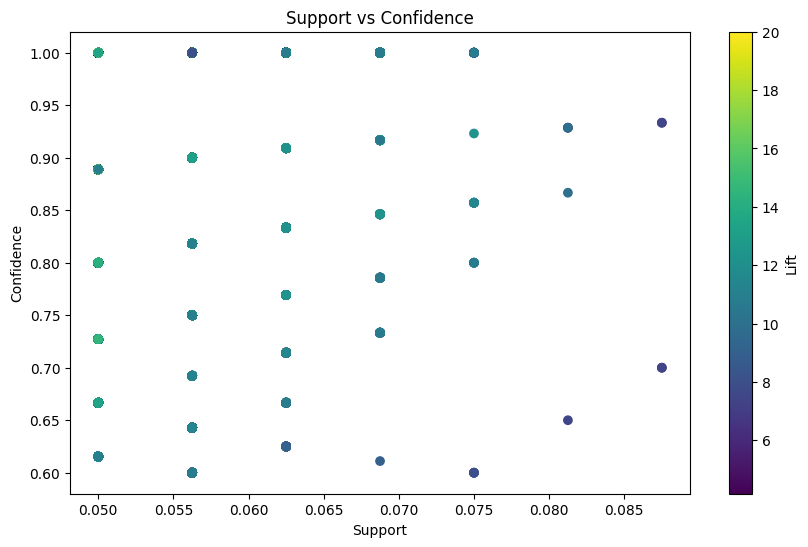

In [19]:

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    rules["support"],
    rules["confidence"],
    c=rules["lift"]
)

plt.xlabel("Support")

plt.ylabel("Confidence")

plt.title("Support vs Confidence")

plt.colorbar(scatter, label="Lift")

plt.show()


## Пояснение к визуализации из задания 6

На рисунке представлена визуализация ассоциативных правил в координатах **support–confidence**.

- По оси **X** откладывается значение support — насколько часто правило встречается в транзакциях.
- По оси **Y** отображается confidence — вероятность появления правой части правила при наличии левой.
- Цвет точки соответствует значению **lift**.

Анализ графика позволяет определить наиболее интересные правила:

- точки выше располагаются правила с высокой confidence, то есть более надёжные;
- точки правее соответствуют правилам с большей поддержкой;
- более яркие точки имеют высокий lift и указывают на сильную связь между товарами.

Наибольший интерес обычно представляют правила:
- с высокой confidence,
- достаточно большим support,
- и lift > 1.

Такие правила могут использоваться для рекомендаций товаров и организации перекрёстных продаж.


# Задание 7. Интерпретация результатов



## Основные выводы

1. Были найдены устойчивые комбинации товаров.
2. Некоторые правила имеют высокий lift.
3. FP-Growth показал лучшую производительность.
4. Ассоциативные правила могут использоваться для рекомендаций и перекрёстных продаж.

## Почему некоторые правила бесполезны?

Даже высокий lift не всегда означает полезность:
- правило может быть очевидным;
- товар может встречаться слишком редко;
- поддержка может быть слишком маленькой.



# Общий вывод

В ходе лабораторной работы были реализованы алгоритмы Apriori и FP-Growth, проведён анализ ассоциативных правил и выполнено сравнение производительности алгоритмов.


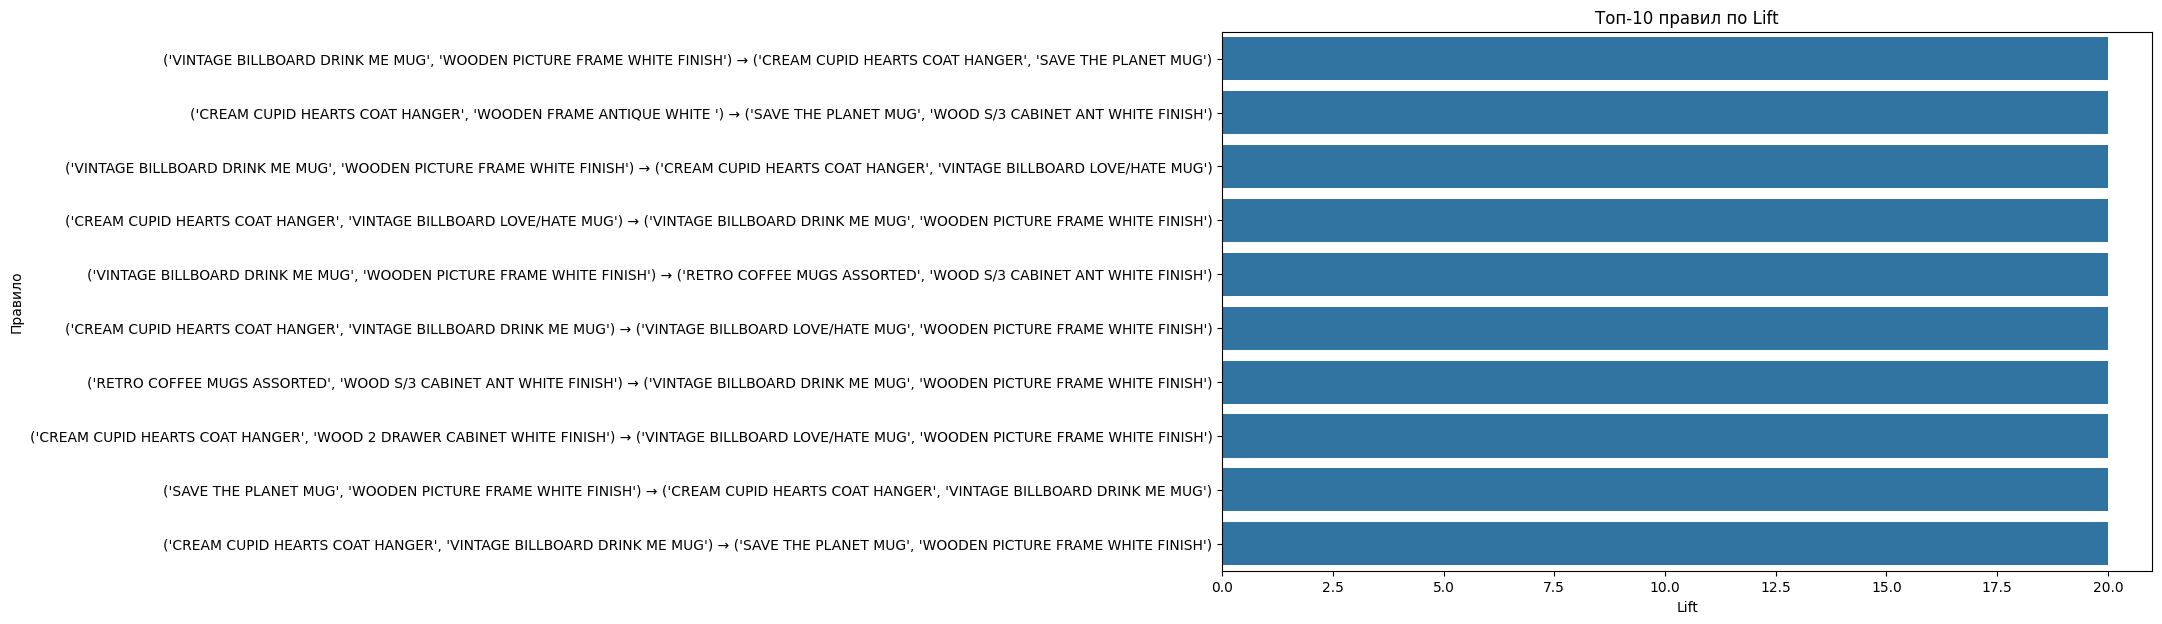

In [20]:

top_rules_plot = top_rules.copy()

top_rules_plot["rule"] = (
    top_rules_plot["antecedent"].astype(str)
    + " → " +
    top_rules_plot["consequent"].astype(str)
)

plt.figure(figsize=(12,7))

sns.barplot(
    data=top_rules_plot,
    y="rule",
    x="lift"
)

plt.title("Топ-10 правил по Lift")

plt.xlabel("Lift")

plt.ylabel("Правило")

plt.show()


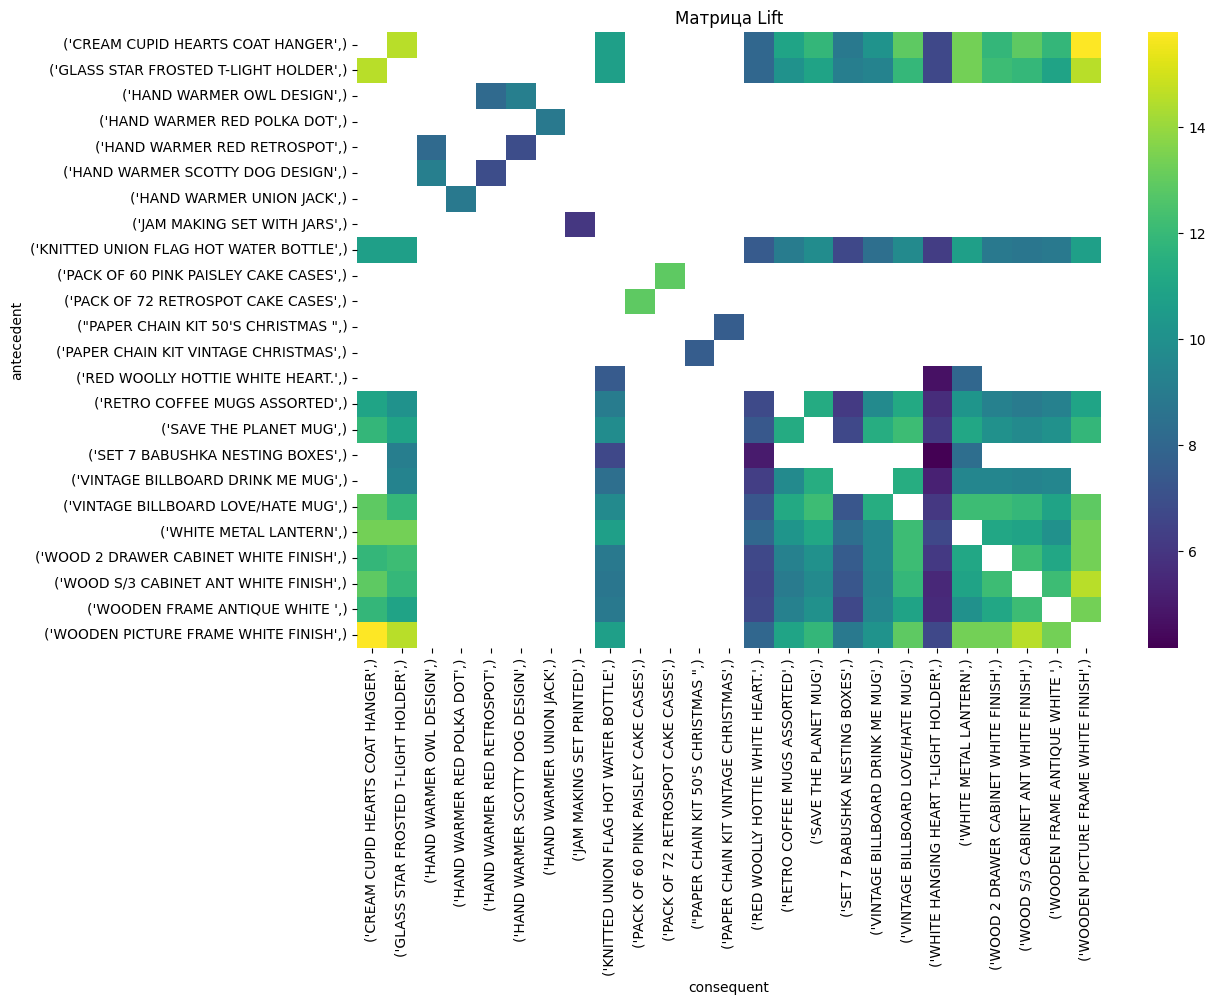

In [21]:

pair_rules = rules[
    (rules["antecedent"].apply(len) == 1) &
    (rules["consequent"].apply(len) == 1)
]

if len(pair_rules) > 0:

    heatmap_data = pair_rules.pivot_table(
        values="lift",
        index="antecedent",
        columns="consequent"
    )

    plt.figure(figsize=(12,8))

    sns.heatmap(
        heatmap_data,
        cmap="viridis"
    )

    plt.title("Матрица Lift")

    plt.show()
